In [5]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
source = "s3://arthurmanceau/election_modeling_uhcp/data/derived/processed/data_processed_presidentiel_legislative_municipales_from1800_to2022_20260605_125905.parquet"

lf = pl.scan_parquet(
    source,
    storage_options={
        "aws_endpoint_url": "https://minio.lab.sspcloud.fr",
        "aws_region": "us-east-1",
    },
    credential_provider=pl.CredentialProviderAWS(
        profile_name="default",
        region_name="us-east-1",
    ),
).collect()

In [42]:
def produce_heatmap(var='pvotepar', election_type='presidentiel', metric='mae', min_year=0, max_year=3000):
    years = sorted(lf.filter(pl.col('election_type')==election_type).filter(pl.col('annee')>min_year).filter(pl.col('annee')<max_year).select('annee').unique().get_column('annee').to_list())
    matrix = np.zeros((len(years), len(years)))
    for i, year1 in enumerate(years):
        for j, year2 in enumerate(years):
            base = lf.filter(pl.col('election_type')==election_type).select(var, 'codecommune', 'annee')
            x1 = base.filter(pl.col('annee')==year1).select(var, 'codecommune')
            x2 = base.filter(pl.col('annee')==year2).select(var, 'codecommune')
            x = x1.join(
                x2, on='codecommune', how='inner', suffix='_next'
            ).with_columns(
                diff =(pl.col(var) - pl.col(f"{var}_next"))
            ).with_columns(
                mae=((pl.col('diff')).abs().mean()),
                mape=(pl.col('diff').abs() / pl.col(var).mean()).mean(),
                mad=((pl.col('diff')).abs().median()),
                mse=((pl.col('diff')).pow(2).mean())
            ).with_columns(
                rmse=pl.col('mse').pow(1/2)
            )
            matrix[i, j] = x.get_column(metric).item(0)

    plt.figure(figsize=(16, 14))
    sns.heatmap(matrix*100, annot=True, cmap="viridis", fmt="g", xticklabels=years, yticklabels=years)
    plt.title(f"Heatmap {var} ({metric})")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()
    return years, matrix

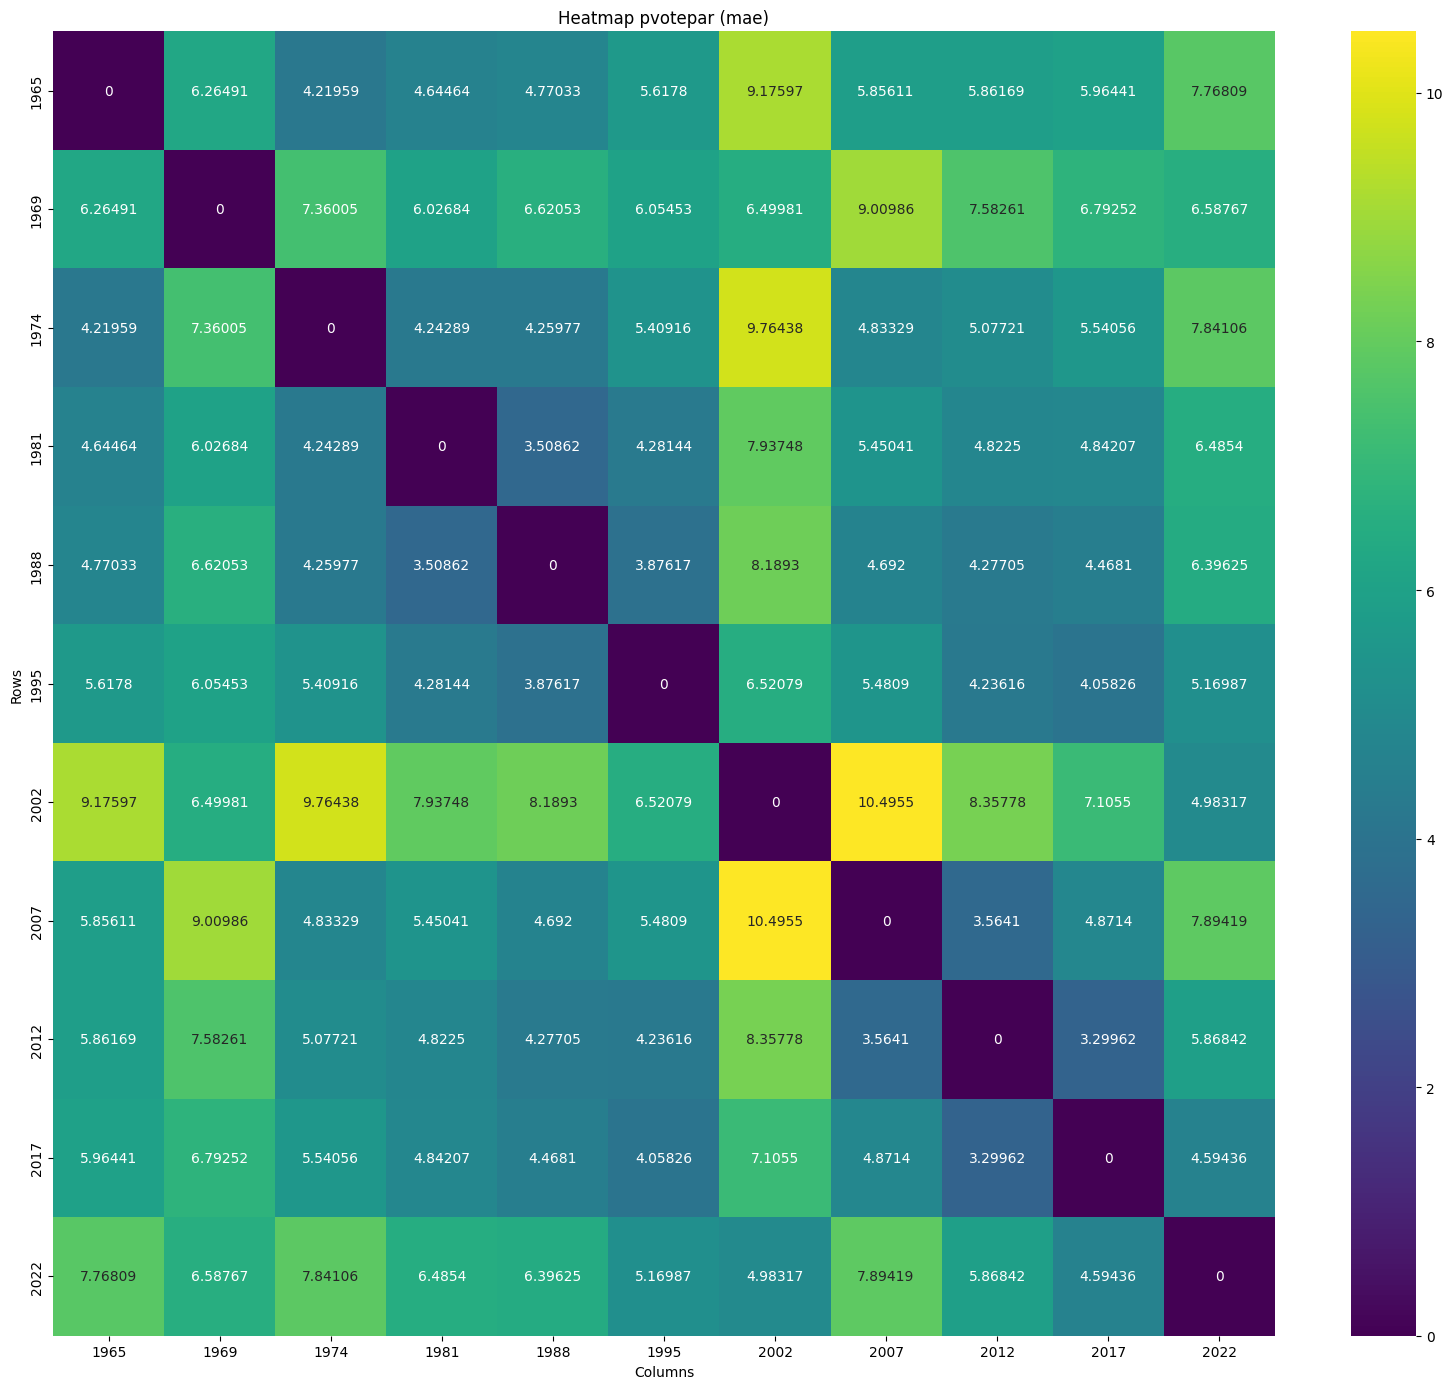

In [55]:
years, matrix = produce_heatmap(var='pvotepar', election_type='presidentiel', metric='mae', min_year=1950)

In [56]:
def plot_backtest_error(k=1):
    backtest_error = np.diag(matrix, k=k)
    plt.plot(years[k:], backtest_error*100)
    plt.title('MAE of a trivial model (past vote)')

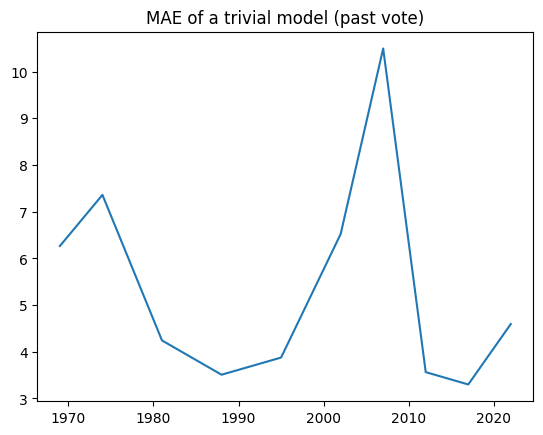

In [57]:
plot_backtest_error(1)

In [18]:
def load_result(var='pvotepar', election_type='pres', year='2017', version='0.2.10'):
    return pl.scan_parquet(
        f"s3://arthurmanceau/election_modeling_uhcp/data/output/results/results_full_{year}_{election_type}_['TD', 'TG', 'par']_{version}.parquet",
        storage_options={
            "aws_endpoint_url": "https://minio.lab.sspcloud.fr",
            "aws_region": "us-east-1",
        },
        credential_provider=pl.CredentialProviderAWS(
            profile_name="default",
            region_name="us-east-1",
        ),
        glob=False
    ).select('codecommune', f'{var}_true', f'{var}_pred').collect()